Epoch 0 | D(real): 0.501 | D(fake): 0.500
Epoch 40 | D(real): 0.501 | D(fake): 0.500
Epoch 80 | D(real): 0.501 | D(fake): 0.500
Epoch 120 | D(real): 0.501 | D(fake): 0.500
Epoch 160 | D(real): 0.501 | D(fake): 0.500


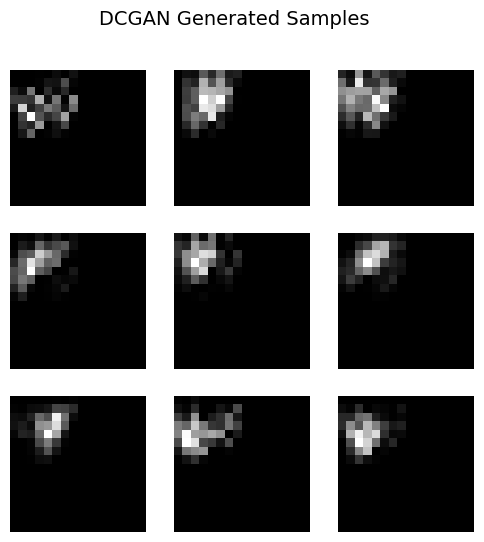

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Basic 2D Convolution (Single-channel)
def conv2d(x, W):
    # x: input image (H x W)
    # W: convolution kernel (kH x kW)
    H, W_img = x.shape
    kH, kW = W.shape

    # Output feature map size
    out = np.zeros((H - kH + 1, W_img - kW + 1))

    # Slide kernel over image
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            # Element-wise multiply and sum
            out[i, j] = np.sum(x[i:i+kH, j:j+kW] * W)

    return out

# Transposed Convolution (Upsampling)
def conv2d_transpose(x, W, out_shape):
    # x: low-resolution feature map
    # W: kernel
    # out_shape: target output size
    out = np.zeros(out_shape)
    kH, kW = W.shape

    # Spread each value back to a larger space
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            out[i:i+kH, j:j+kW] += x[i, j] * W

    return out

# Activation Functions
def relu(x):
    # Used in Generator
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.2):
    # Used in Discriminator (prevents dying neurons)
    return np.where(x > 0, x, alpha * x)

def sigmoid(x):
    # Converts score → probability
    return 1 / (1 + np.exp(-x))

# Generate Simple Real Images
def generate_real_images(n=100):
    # Create images with a bright square in center
    imgs = []
    for _ in range(n):
        img = np.zeros((16, 16))
        cx, cy = np.random.randint(4, 12, size=2)
        img[cx-2:cx+2, cy-2:cy+2] = 1  # white square
        imgs.append(img)
    return np.array(imgs)

# Generator Weights
Wg1 = np.random.randn(3,3) * 0.1
Wg2 = np.random.randn(3,3) * 0.1

# Generator Network
def generator(z):
    # z: random noise (16,)
    x = z.reshape(4,4)                # reshape noise → 4x4
    x = relu(conv2d_transpose(x, Wg1, (8,8)))   # upsample → 8x8
    x = relu(conv2d_transpose(x, Wg2, (16,16))) # upsample → 16x16
    return x

# Discriminator Weights
Wd1 = np.random.randn(3,3) * 0.1
Wd2 = np.random.randn(3,3) * 0.1

# Discriminator Network
def discriminator(x):
    # x: image (16x16)
    x = leaky_relu(conv2d(x, Wd1))     # extract features
    x = leaky_relu(conv2d(x, Wd2))     # deeper features
    return sigmoid(np.mean(x))         # average → probability

# Dataset
real_data = generate_real_images(200)
epochs = 200

# Training Loop (Forward-only)
for epoch in range(epochs):
    # Pick random real image
    real = real_data[np.random.randint(len(real_data))]

    # Sample random noise
    z = np.random.randn(16)

    # Generate fake image
    fake = generator(z)

    # Discriminator predictions
    d_real = discriminator(real)
    d_fake = discriminator(fake)

    # Print progress
    if epoch % 40 == 0:
        print(f"Epoch {epoch} | D(real): {d_real:.3f} | D(fake): {d_fake:.3f}")

# Visualization of Generated Images
plt.figure(figsize=(6,6))

for i in range(9):
    z = np.random.randn(16)
    img = generator(z)

    plt.subplot(3,3,i+1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")

plt.suptitle("DCGAN Generated Samples", fontsize=14)
plt.show()
